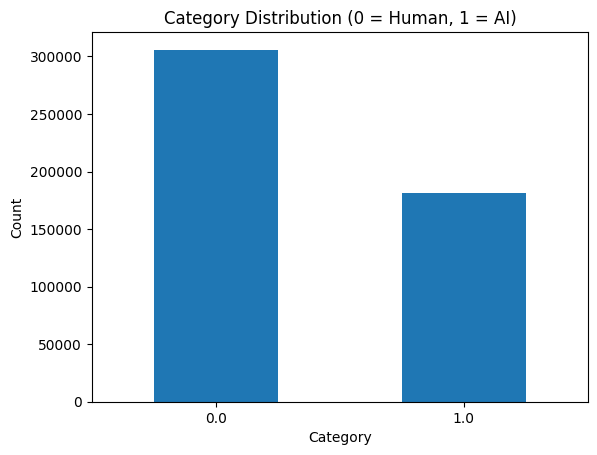

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
dataframe = pd.read_csv("dataset/AI_Human.csv")

# Count categories
category_counts = dataframe["generated"].value_counts().sort_index()

# Plot
plt.figure()
category_counts.plot(kind="bar")
plt.title("Category Distribution (0 = Human, 1 = AI)")
plt.xlabel("Category")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

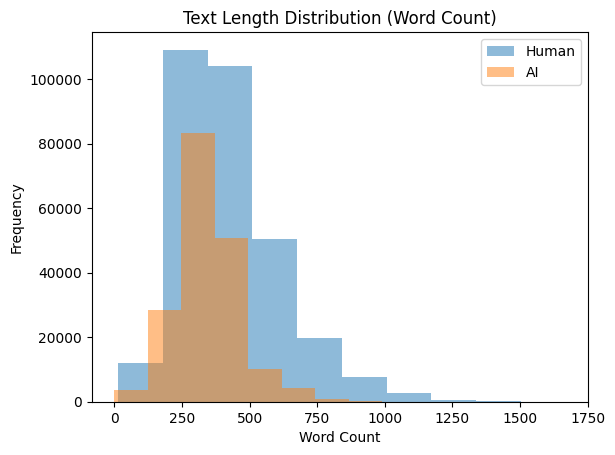

In [3]:
# Create word count column
dataframe["word_count"] = dataframe["text"].apply(lambda text: len(str(text).split()))

# Plot histogram
plt.figure()
plt.hist(dataframe[dataframe["generated"] == 0]["word_count"], alpha=0.5, label="Human")
plt.hist(dataframe[dataframe["generated"] == 1]["word_count"], alpha=0.5, label="AI")
plt.title("Text Length Distribution (Word Count)")
plt.xlabel("Word Count")
plt.ylabel("Frequency")
plt.legend()
plt.show()

In [4]:
from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np

def get_top_tfidf_words(text_series, top_n=20):
    vectorizer = TfidfVectorizer(max_features=1000)
    tfidf_matrix = vectorizer.fit_transform(text_series)

    # Average TF-IDF score per word
    mean_tfidf = np.asarray(tfidf_matrix.mean(axis=0)).flatten()
    feature_names = vectorizer.get_feature_names_out()

    # Get top words
    top_indices = mean_tfidf.argsort()[::-1][:top_n]
    top_words = [feature_names[i] for i in top_indices]
    top_scores = mean_tfidf[top_indices]

    return top_words, top_scores

# Split dataset
human_texts = dataframe[dataframe["generated"] == 0]["text"]
ai_texts = dataframe[dataframe["generated"] == 1]["text"]

# Get top words
human_words, human_scores = get_top_tfidf_words(human_texts)
ai_words, ai_scores = get_top_tfidf_words(ai_texts)

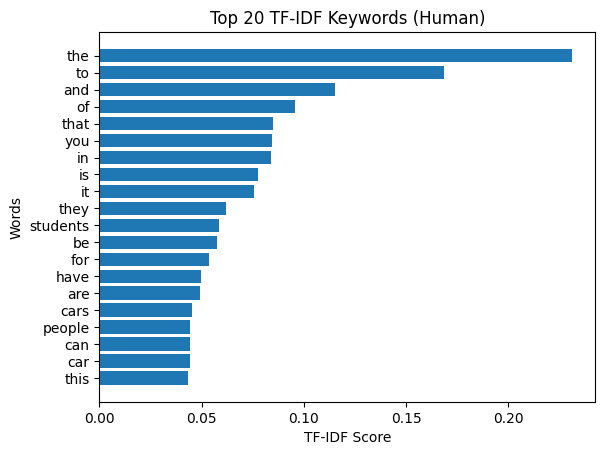

In [5]:
plt.figure()
plt.barh(human_words[::-1], human_scores[::-1])
plt.title("Top 20 TF-IDF Keywords (Human)")
plt.xlabel("TF-IDF Score")
plt.ylabel("Words")
plt.show()

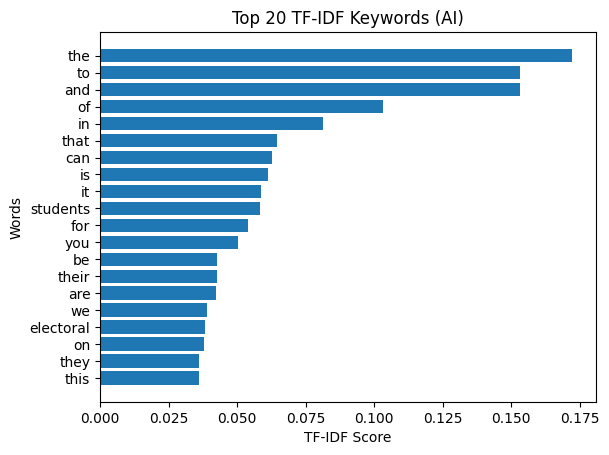

In [6]:
plt.figure()
plt.barh(ai_words[::-1], ai_scores[::-1])
plt.title("Top 20 TF-IDF Keywords (AI)")
plt.xlabel("TF-IDF Score")
plt.ylabel("Words")
plt.show()